# Deliverable 3 / Task 2 - DeiT Transformer Architectures for Dense Depth

This notebook is configured for a local run from the repository root. It uses **DeiT-Small** as the transformer encoder family, because DeiT naturally supports the assignment's patch-size 8 vs 16 comparison while staying close to the requested ImageNet-pretrained transformer setup.

Task 1 already selected the final data pipeline for the CNN baseline: `256_nearest`, no augmentation, `lr=1e-3`, `batch_size=8`. Task 2 reuses the same resized dataset root and compares transformer design choices in a staged way:

1. Decoder: bilinear upsampling vs lightweight FPN.
2. Patch size: 16 vs 8 using DeiT-Small ImageNet pretrained weights with timm's patch/position resampling.
3. Transfer learning: full fine-tuning vs frozen backbone.
4. Final transformer vs UNet baseline from Task 1.

Every run uses 8 epochs, writes metrics/checkpoints/histories to `runs/d2_deit`, and skips exact configurations that already have saved metrics or checkpoints.


## 1 - Local Setup


In [1]:
from pathlib import Path
import gc, json, os, pickle, random, time

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from torchinfo import summary

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'preprocessed_data' / 'resized_variants' / '256_nearest'
D1_RESULTS = PROJECT_ROOT / 'runs' / 'd1_unet' / 'd1_results.csv'

RUNS_ROOT = PROJECT_ROOT / 'runs' / 'd2_deit'
FIG_ROOT = RUNS_ROOT / 'figures'
CKPT_ROOT = RUNS_ROOT / 'checkpoints'
HIST_ROOT = RUNS_ROOT / 'histories'
METRIC_ROOT = RUNS_ROOT / 'metrics'

for p in [RUNS_ROOT, FIG_ROOT, CKPT_ROOT, HIST_ROOT, METRIC_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'Device : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')
else:
    print('Device : CPU')

NUM_WORKERS = 0 if os.name == 'nt' else 2
print(f'timm   : {timm.__version__}')
print(f'Data   : {DATA_ROOT}')
print(f'Runs   : {RUNS_ROOT}')
assert DATA_ROOT.exists(), f'Missing data root: {DATA_ROOT}'


c:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : NVIDIA GeForce RTX 4070
CUDA   : 12.1
timm   : 1.0.27
Data   : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\preprocessed_data\resized_variants\256_nearest
Runs   : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit


## 2 - Dataset


In [2]:
def read_list(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]


train_list = read_list(DATA_ROOT / 'train.txt')
val_list = read_list(DATA_ROOT / 'validation.txt')
test_list = read_list(DATA_ROOT / 'test.txt')
print(f'Train: {len(train_list)}  Val: {len(val_list)}  Test: {len(test_list)}')

missing = []
for name in train_list + val_list + test_list:
    if not (DATA_ROOT / 'image' / f'{name}.jpg').exists() or not (DATA_ROOT / 'depth' / f'{name}.npy').exists():
        missing.append(name)
print(f'Missing image/depth pairs: {len(missing)}')
assert not missing, missing[:10]


Train: 30325  Val: 3283  Test: 2827
Missing image/depth pairs: 0


In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class Cloth3DDataset(Dataset):
    def __init__(self, data_list, root, img_size=256):
        self.data_list = data_list
        self.root = Path(root)
        self.img_size = img_size

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        name = self.data_list[idx]
        img = cv2.imread(str(self.root / 'image' / f'{name}.jpg'))
        if img is None:
            raise RuntimeError(f'Could not read image: {name}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        dpt = np.load(self.root / 'depth' / f'{name}.npy').astype(np.float32)

        s = self.img_size
        if img.shape[:2] != (s, s):
            img = cv2.resize(img, (s, s), interpolation=cv2.INTER_LINEAR)
            dpt = cv2.resize(dpt, (s, s), interpolation=cv2.INTER_NEAREST)

        mask = dpt > 0
        if mask.any():
            dpt[mask] = (dpt[mask] - dpt[mask].min() + 0.001) / 2.0

        # ImageNet normalization is used because the encoder is ImageNet-pretrained.
        img = (img - IMAGENET_MEAN) / IMAGENET_STD

        img = torch.from_numpy(img).permute(2, 0, 1).float()
        dpt = torch.from_numpy(dpt).unsqueeze(0).float()
        return img, dpt


## 3 - DeiT Encoder and Decoders


In [4]:
class DeiTEncoder(nn.Module):
    def __init__(self, patch_size=16, pretrained=True, img_size=256):
        super().__init__()
        self.patch_size = patch_size
        self.backbone = timm.create_model(
            'deit_small_patch16_224',
            pretrained=pretrained,
            img_size=img_size,
            patch_size=patch_size,
            num_classes=0,
        )
        self.embed_dim = self.backbone.embed_dim
        self.out_channels = [self.embed_dim]

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        if feats.ndim != 3:
            raise RuntimeError(f'Unexpected DeiT feature shape: {feats.shape}')
        patches = feats[:, 1:] if feats.shape[1] > 1 else feats
        side = int(patches.shape[1] ** 0.5)
        return [patches.reshape(x.shape[0], side, side, -1).permute(0, 3, 1, 2).contiguous()]


class BilinearDecoder(nn.Module):
    def __init__(self, in_channels_list, target_size=256):
        super().__init__()
        self.target_size = target_size
        in_ch = in_channels_list[-1]
        self.refine = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, features):
        x = features[-1]
        x = F.interpolate(x, size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
        return self.refine(x)


class FPNDecoder(nn.Module):
    def __init__(self, in_channels_list, target_size=256, fpn_channels=128):
        super().__init__()
        self.target_size = target_size
        self.proj = nn.Conv2d(in_channels_list[-1], fpn_channels, 1)
        self.head = nn.Sequential(
            nn.Conv2d(fpn_channels, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, features):
        x = self.proj(features[-1])
        x = F.interpolate(x, size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
        return self.head(x)


class DepthModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        return self.decoder(self.encoder(x))


def build_model(cfg):
    encoder = DeiTEncoder(
        patch_size=cfg['patch_size'],
        pretrained=cfg['pretrained'],
        img_size=cfg['img_size'],
    )
    if cfg['decoder'] == 'bilinear':
        decoder = BilinearDecoder(encoder.out_channels, target_size=cfg['img_size'])
    elif cfg['decoder'] == 'fpn':
        decoder = FPNDecoder(encoder.out_channels, target_size=cfg['img_size'])
    else:
        raise ValueError(cfg['decoder'])
    return DepthModel(encoder, decoder)


def apply_transfer_learning(model, mode):
    if mode == 'full_finetune':
        for p in model.parameters():
            p.requires_grad = True
    elif mode == 'frozen_backbone':
        for p in model.encoder.parameters():
            p.requires_grad = False
        for p in model.decoder.parameters():
            p.requires_grad = True
    else:
        raise ValueError(mode)
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Transfer: {mode} | trainable {trainable:,}/{total:,} ({100*trainable/total:.1f}%)')


## 4 - Metrics


In [5]:
def rmse(pred, gt):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    return torch.sqrt(F.mse_loss(pred[mask], gt[mask]))


def depth_to_normals(depth, eps=1e-6):
    dz_dx = depth[:, :, :, 2:] - depth[:, :, :, :-2]
    dz_dy = depth[:, :, 2:, :] - depth[:, :, :-2, :]
    dz_dx = F.pad(dz_dx, [1, 1, 0, 0])
    dz_dy = F.pad(dz_dy, [0, 0, 1, 1])
    n = torch.cat([-dz_dx, -dz_dy, torch.ones_like(dz_dx)], dim=1)
    return n / (torch.norm(n, dim=1, keepdim=True) + eps)


def mean_angular_error(pred_depth, gt_depth):
    mask = (gt_depth > 0).squeeze(1)
    n_pred = depth_to_normals(pred_depth)
    n_gt = depth_to_normals(gt_depth)
    cos_sim = (n_pred * n_gt).sum(dim=1).clamp(-1.0, 1.0)
    angle = torch.acos(cos_sim) * (180.0 / torch.pi)
    if not mask.any():
        return torch.tensor(0.0, device=pred_depth.device)
    return angle[mask].mean()


## 5 - Training and Caching


In [6]:
BASE_CONFIG = {
    'root': DATA_ROOT,
    'img_size': 256,
    'encoder': 'deit_small',
    'decoder': 'bilinear',
    'patch_size': 16,
    'transfer': 'full_finetune',
    'pretrained': True,
    'batch_size': 4,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'epochs': 8,
    'patience': 8,
    'seed': 42,
    'resume': True,
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def slugify(label):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in label).strip('_')


def build_label(cfg):
    return f'deit_p{cfg["patch_size"]}_{cfg["decoder"]}_{cfg["transfer"]}_lr{cfg["lr"]:.0e}_bs{cfg["batch_size"]}'.replace('+0', '').replace('-0', '-')


def build_cfg(overrides):
    cfg = {**BASE_CONFIG, **overrides}
    cfg['root'] = Path(cfg['root'])
    label = build_label(cfg)
    tag = slugify(label)
    cfg['label'] = label
    cfg['checkpoint'] = CKPT_ROOT / f'model_{tag}.pth'
    cfg['latest_checkpoint'] = CKPT_ROOT / f'latest_{tag}.pth'
    cfg['history_path'] = HIST_ROOT / f'hist_{tag}.pkl'
    cfg['result_path'] = METRIC_ROOT / f'result_{tag}.json'
    return cfg


def make_loader(data_list, cfg, shuffle, batch_size=None):
    ds = Cloth3DDataset(data_list, cfg['root'], cfg['img_size'])
    return DataLoader(
        ds,
        batch_size=batch_size or cfg['batch_size'],
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == 'cuda'),
    )


def result_from_cfg(cfg, status='ok', **metrics):
    return {
        'label': cfg['label'],
        'status': status,
        'val_rmse': metrics.get('val_rmse', float('inf')),
        'test_rmse': metrics.get('test_rmse', float('inf')),
        'normal_mae': metrics.get('normal_mae', float('inf')),
        'fps': metrics.get('fps', 0.0),
        'params': metrics.get('params', 0),
        'trainable_params': metrics.get('trainable_params', 0),
        'gpu_mb': metrics.get('gpu_mb', 0.0),
        'img_size': cfg['img_size'],
        'decoder': cfg['decoder'],
        'patch_size': cfg['patch_size'],
        'transfer': cfg['transfer'],
        'pretrained': cfg['pretrained'],
        'lr': cfg['lr'],
        'batch_size': cfg['batch_size'],
        'checkpoint': str(cfg['checkpoint']),
        'history_path': str(cfg['history_path']),
        'result_path': str(cfg['result_path']),
    }


def save_result(result):
    Path(result['result_path']).write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result


def load_result(cfg):
    if cfg['result_path'].exists():
        result = json.loads(cfg['result_path'].read_text(encoding='utf-8'))
        print(f'Found saved metrics: {cfg["result_path"].name}; skipping training.')
        return result
    if cfg['checkpoint'].exists() and cfg['history_path'].exists():
        print(f'Found checkpoint/history for {cfg["label"]}; evaluating once.')
        model = build_model(cfg).to(DEVICE)
        apply_transfer_learning(model, cfg['transfer'])
        history = pickle.load(open(cfg['history_path'], 'rb'))
        cfg['history_val_rmse'] = history.get('val_rmse', [])
        result = evaluate(model, test_list, cfg)
        result['val_rmse'] = min(history.get('val_rmse', [float('inf')]))
        return save_result(result)
    return None


def cleanup_cuda():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


In [7]:
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for X, Y in loader:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        pred = model(X)
        loss = F.mse_loss(pred, Y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(1, len(loader))


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_rmse, total_mae, n = 0.0, 0.0, 0
    for X, Y in loader:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        pred = model(X)
        total_rmse += rmse(pred, Y).item()
        total_mae += mean_angular_error(pred, Y).item()
        n += 1
    return total_rmse / max(1, n), total_mae / max(1, n)


def save_latest(path, model, optimizer, scheduler, epoch, best_rmse, history):
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'best_rmse': best_rmse,
        'history': history,
    }, path)


def train(model, cfg):
    train_dl = make_loader(train_list, cfg, shuffle=True)
    val_dl = make_loader(val_list, cfg, shuffle=False)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'],
        weight_decay=cfg['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    history = {'train_loss': [], 'val_rmse': [], 'val_mae_n': [], 'epoch_seconds': []}
    best_rmse = float('inf')
    start_epoch = 0

    if cfg['latest_checkpoint'].exists() and cfg.get('resume', True):
        print(f'Resuming from {cfg["latest_checkpoint"]}')
        ckpt = torch.load(cfg['latest_checkpoint'], map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_rmse = ckpt['best_rmse']
        history = ckpt['history']

    for epoch in range(start_epoch, cfg['epochs']):
        t0 = time.time()
        tr_loss = train_epoch(model, train_dl, optimizer)
        v_rmse, v_mae = val_epoch(model, val_dl)
        scheduler.step()
        elapsed = time.time() - t0
        history['train_loss'].append(tr_loss)
        history['val_rmse'].append(v_rmse)
        history['val_mae_n'].append(v_mae)
        history['epoch_seconds'].append(elapsed)
        print(f'Epoch {epoch+1:02d}/{cfg["epochs"]} | loss={tr_loss:.4f} | val_RMSE={v_rmse:.4f} | val_NormalMAE={v_mae:.2f} deg | {elapsed:.1f}s')
        if v_rmse < best_rmse:
            best_rmse = v_rmse
            torch.save(model.state_dict(), cfg['checkpoint'])
        save_latest(cfg['latest_checkpoint'], model, optimizer, scheduler, epoch, best_rmse, history)

    with open(cfg['history_path'], 'wb') as fh:
        pickle.dump(history, fh)
    print(f'Best val RMSE: {best_rmse:.4f}')
    return history, best_rmse


@torch.no_grad()
def evaluate(model, test_list, cfg):
    model.eval()
    model.load_state_dict(torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True))
    test_dl = make_loader(test_list, cfg, shuffle=False, batch_size=1)
    total_rmse, total_mae = 0.0, 0.0
    fps_times = []
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    for X, Y in test_dl:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        pred = model(X)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        fps_times.append(time.time() - t0)
        total_rmse += rmse(pred, Y).item()
        total_mae += mean_angular_error(pred, Y).item()
    n = len(test_dl)
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gpu_mb = torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == 'cuda' else 0.0
    fps = 1.0 / (sum(fps_times) / len(fps_times))
    result = result_from_cfg(
        cfg,
        val_rmse=min(cfg.get('history_val_rmse', [float('inf')])),
        test_rmse=total_rmse / n,
        normal_mae=total_mae / n,
        fps=fps,
        params=params,
        trainable_params=trainable,
        gpu_mb=gpu_mb,
    )
    print('=' * 72)
    print(cfg['label'])
    print(f'  Test RMSE         : {result["test_rmse"]:.4f}')
    print(f'  Normal MAE        : {result["normal_mae"]:.2f} deg')
    print(f'  FPS               : {result["fps"]:.1f}')
    print(f'  Parameters        : {result["params"]:,}')
    print(f'  Trainable params  : {result["trainable_params"]:,}')
    print(f'  Peak GPU mem (MB) : {result["gpu_mb"]:.1f}')
    print('=' * 72)
    return result


In [8]:
results = []


def append_and_save(result):
    existing = {r['label']: r for r in results}
    existing[result['label']] = result
    results.clear()
    results.extend(existing.values())
    pd.DataFrame(results).to_csv(RUNS_ROOT / 'd2_results_so_far.csv', index=False)


def run_exp(overrides):
    cfg = build_cfg(overrides)
    print('\n' + '#' * 72)
    print(f'RUN: {cfg["label"]}')
    print('#' * 72)
    cached = load_result(cfg)
    if cached is not None:
        append_and_save(cached)
        return cached
    try:
        set_seed(cfg['seed'])
        model = build_model(cfg).to(DEVICE)
        apply_transfer_learning(model, cfg['transfer'])
        history, best_val_rmse = train(model, cfg)
        cfg['history_val_rmse'] = history['val_rmse']
        result = evaluate(model, test_list, cfg)
        result['val_rmse'] = best_val_rmse
        result = save_result(result)
    except RuntimeError as exc:
        if 'out of memory' in str(exc).lower():
            print(f'OOM during {cfg["label"]}; recording failed run.')
            result = save_result(result_from_cfg(cfg, status='failed_oom'))
        else:
            raise
    finally:
        cleanup_cuda()
    append_and_save(result)
    return result


def summarize_group(title, group_results):
    cols = ['label', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'fps', 'gpu_mb', 'params', 'trainable_params']
    df_group = pd.DataFrame(group_results)[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
    print('\n' + '=' * 72)
    print(title)
    print('=' * 72)
    print(df_group.to_string(index=False))
    ok = [r for r in group_results if r['status'] == 'ok']
    best = min(ok, key=lambda r: r['val_rmse'])
    print(f'\nDecision: {best["label"]} selected by lowest validation RMSE ({best["val_rmse"]:.4f}).')
    return best, df_group


## 6 - Run Staged Experiments


In [9]:
# Stage 1: decoder comparison with the standard DeiT-S p16 full fine-tuning setup.
decoder_results = [
    run_exp({'patch_size': 16, 'decoder': 'bilinear', 'transfer': 'full_finetune'}),
    run_exp({'patch_size': 16, 'decoder': 'fpn', 'transfer': 'full_finetune'}),
]
best_decoder_result, decoder_table = summarize_group('Stage 1 decision - decoder design', decoder_results)
BEST_DECODER = best_decoder_result['decoder']

# Stage 2: patch size comparison using the selected decoder.
patch_results = [
    run_exp({'patch_size': 16, 'decoder': BEST_DECODER, 'transfer': 'full_finetune'}),
    run_exp({'patch_size': 8, 'decoder': BEST_DECODER, 'transfer': 'full_finetune'}),
]
best_patch_result, patch_table = summarize_group('Stage 2 decision - patch size', patch_results)
BEST_PATCH_SIZE = best_patch_result['patch_size']

# Stage 3: transfer learning comparison using the selected decoder and patch size.
transfer_results = [
    run_exp({'patch_size': BEST_PATCH_SIZE, 'decoder': BEST_DECODER, 'transfer': 'full_finetune'}),
    run_exp({'patch_size': BEST_PATCH_SIZE, 'decoder': BEST_DECODER, 'transfer': 'frozen_backbone'}),
]
best_transfer_result, transfer_table = summarize_group('Stage 3 decision - transfer learning', transfer_results)

STAGE_DECISIONS = {
    'best_decoder': best_decoder_result,
    'best_patch_size': best_patch_result,
    'best_transfer': best_transfer_result,
}
(RUNS_ROOT / 'd2_stage_decisions.json').write_text(json.dumps(STAGE_DECISIONS, indent=2), encoding='utf-8')



########################################################################
RUN: deit_p16_bilinear_full_finetune_lr1e-4_bs4
########################################################################
Transfer: full_finetune | trainable 22,943,489/22,943,489 (100.0%)
Epoch 01/8 | loss=0.0069 | val_RMSE=0.0884 | val_NormalMAE=1.56 deg | 1535.7s
Epoch 02/8 | loss=0.0005 | val_RMSE=0.0804 | val_NormalMAE=1.45 deg | 1532.6s
Epoch 03/8 | loss=0.0004 | val_RMSE=0.0828 | val_NormalMAE=1.39 deg | 1530.0s
Epoch 04/8 | loss=0.0003 | val_RMSE=0.0772 | val_NormalMAE=1.34 deg | 1530.0s
Epoch 05/8 | loss=0.0002 | val_RMSE=0.0780 | val_NormalMAE=1.33 deg | 1534.1s
Epoch 06/8 | loss=0.0002 | val_RMSE=0.0776 | val_NormalMAE=1.30 deg | 1550.8s
Epoch 07/8 | loss=0.0002 | val_RMSE=0.0775 | val_NormalMAE=1.29 deg | 1619.3s
Epoch 08/8 | loss=0.0002 | val_RMSE=0.0779 | val_NormalMAE=1.30 deg | 1626.1s
Best val RMSE: 0.0772
deit_p16_bilinear_full_finetune_lr1e-4_bs4
  Test RMSE         : 0.0578
  Normal MAE        

Transfer: full_finetune | trainable 23,017,217/23,017,217 (100.0%)
Epoch 01/8 | loss=0.0058 | val_RMSE=0.0880 | val_NormalMAE=1.39 deg | 1834.3s
Epoch 02/8 | loss=0.0004 | val_RMSE=0.0816 | val_NormalMAE=1.27 deg | 1846.3s
Epoch 03/8 | loss=0.0003 | val_RMSE=0.0798 | val_NormalMAE=1.25 deg | 1835.6s
Epoch 04/8 | loss=0.0002 | val_RMSE=0.0746 | val_NormalMAE=1.21 deg | 1772.7s
Epoch 05/8 | loss=0.0002 | val_RMSE=0.0749 | val_NormalMAE=1.18 deg | 1773.3s
Epoch 06/8 | loss=0.0002 | val_RMSE=0.0737 | val_NormalMAE=1.17 deg | 1773.3s
Epoch 07/8 | loss=0.0001 | val_RMSE=0.0735 | val_NormalMAE=1.16 deg | 1773.9s
Epoch 08/8 | loss=0.0001 | val_RMSE=0.0737 | val_NormalMAE=1.16 deg | 1956.7s
Best val RMSE: 0.0735
deit_p8_bilinear_full_finetune_lr1e-4_bs4
  Test RMSE         : 0.0537
  Normal MAE        : 1.02 deg
  FPS               : 61.5
  Parameters        : 23,017,217
  Trainable params  : 23,017,217
  Peak GPU mem (MB) : 425.5

Stage 2 decision - patch size
                                 

2982

## 7 - Final Tables and CNN Baseline Comparison


In [10]:
df = pd.DataFrame(results)
cols = [
    'label', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'fps', 'params', 'trainable_params', 'gpu_mb',
    'patch_size', 'decoder', 'transfer', 'pretrained', 'lr', 'batch_size',
    'checkpoint', 'history_path', 'result_path',
]
for col in cols:
    if col not in df.columns:
        df[col] = None
df = df[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
df['params_m'] = df['params'] / 1e6
df['trainable_m'] = df['trainable_params'] / 1e6
summary_path = RUNS_ROOT / 'd2_results.csv'
df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')
print(df.to_string(index=False))

if D1_RESULTS.exists():
    d1 = pd.read_csv(D1_RESULTS)
    unet = d1[d1['label'] == '256_nearest_no_aug_lr1e-3_bs8']
    if len(unet) == 0:
        unet = d1.sort_values('val_rmse').head(1)
    unet_row = unet.iloc[0]
    best_transformer = STAGE_DECISIONS['best_transfer']
    comparison = pd.DataFrame([
        {
            'model': 'UNet CNN baseline',
            'val_rmse': unet_row['val_rmse'],
            'test_rmse': unet_row['test_rmse'],
            'normal_mae': unet_row['normal_mae'],
            'fps': unet_row['fps'],
            'params_m': unet_row['params'] / 1e6,
            'gpu_mb': unet_row['gpu_mb'],
        },
        {
            'model': best_transformer['label'],
            'val_rmse': best_transformer['val_rmse'],
            'test_rmse': best_transformer['test_rmse'],
            'normal_mae': best_transformer['normal_mae'],
            'fps': best_transformer['fps'],
            'params_m': best_transformer['params'] / 1e6,
            'gpu_mb': best_transformer['gpu_mb'],
        },
    ])
    comparison.to_csv(RUNS_ROOT / 'd2_vs_unet.csv', index=False)
    print('\nCNN vs best DeiT transformer:')
    print(comparison.to_string(index=False))


Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit\d2_results.csv
                                      label status  val_rmse  test_rmse  normal_mae       fps   params  trainable_params     gpu_mb  patch_size  decoder        transfer  pretrained     lr  batch_size                                                                                                                              checkpoint                                                                                                                         history_path                                                                                                                           result_path  params_m  trainable_m
  deit_p8_bilinear_full_finetune_lr1e-4_bs4     ok  0.073467   0.053720    1.015298 61.515567 23017217          23017217 425.530273           8 bilinear   full_finetune        True 0.0001           4   C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit\checkpoint

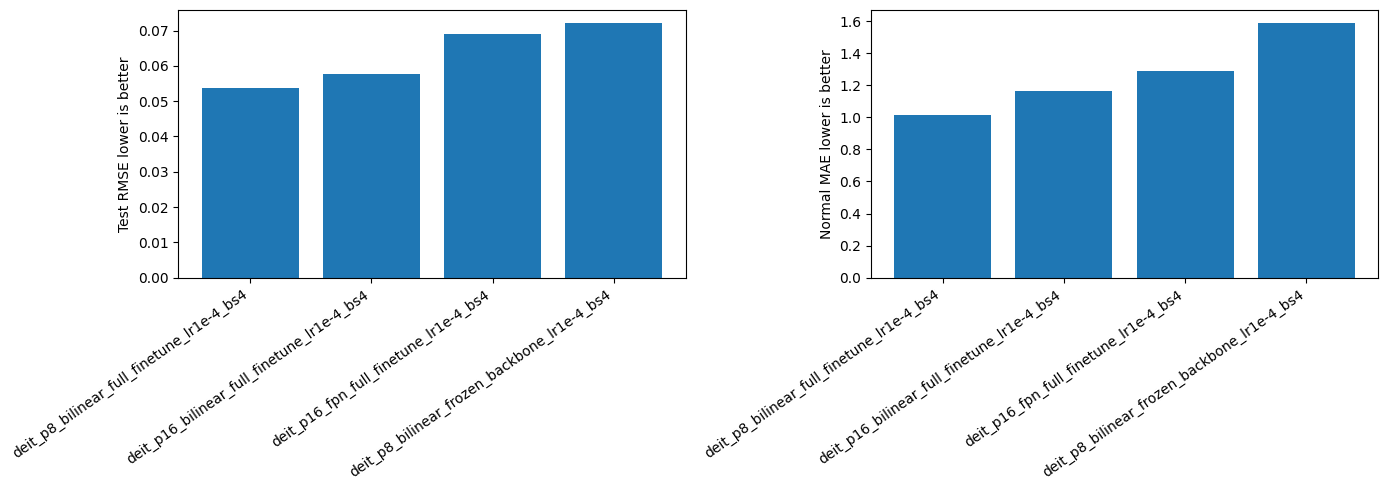

In [11]:
plot_df = df[df['status'] == 'ok'].copy()
if len(plot_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(plot_df))
    axes[0].bar(x, plot_df['test_rmse'])
    axes[0].set_ylabel('Test RMSE lower is better')
    axes[1].bar(x, plot_df['normal_mae'])
    axes[1].set_ylabel('Normal MAE lower is better')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['label'], rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_ROOT / 'd2_results.png', dpi=150)
    plt.show()


## 8 - Architecture and Efficiency Summary


In [12]:
arch_configs = [
    {'patch_size': 16, 'decoder': 'bilinear', 'transfer': 'full_finetune'},
    {'patch_size': 16, 'decoder': 'fpn', 'transfer': 'full_finetune'},
    {'patch_size': 8, 'decoder': BEST_DECODER, 'transfer': 'full_finetune'},
    {'patch_size': BEST_PATCH_SIZE, 'decoder': BEST_DECODER, 'transfer': 'frozen_backbone'},
]

arch_stats = []
for overrides in arch_configs:
    cfg = build_cfg(overrides)
    model = build_model(cfg).to(DEVICE)
    apply_transfer_learning(model, cfg['transfer'])
    label = cfg['label']
    print('\n' + '=' * 72)
    print(label)
    print('=' * 72)
    try:
        s = summary(model, input_size=(1, 3, cfg['img_size'], cfg['img_size']), verbose=0,
                    col_names=['input_size', 'output_size', 'num_params', 'mult_adds'])
        arch_stats.append({
            'label': label,
            'params': s.total_params,
            'trainable': sum(p.numel() for p in model.parameters() if p.requires_grad),
            'gmacs': s.total_mult_adds / 1e9,
        })
        print(f'Params: {s.total_params/1e6:.2f}M | GMACs: {s.total_mult_adds/1e9:.2f}')
    except Exception as exc:
        print(f'torchinfo failed for {label}: {exc}')
    del model
    cleanup_cuda()

arch_df = pd.DataFrame(arch_stats)
arch_df.to_csv(RUNS_ROOT / 'd2_architecture_stats.csv', index=False)
print(arch_df.to_string(index=False))


Transfer: full_finetune | trainable 22,943,489/22,943,489 (100.0%)

deit_p16_bilinear_full_finetune_lr1e-4_bs4
Params: 22.94M | GMACs: 82.27
Transfer: full_finetune | trainable 21,959,809/21,959,809 (100.0%)

deit_p16_fpn_full_finetune_lr1e-4_bs4
Params: 21.96M | GMACs: 14.62
Transfer: full_finetune | trainable 23,017,217/23,017,217 (100.0%)

deit_p8_bilinear_full_finetune_lr1e-4_bs4
Params: 23.02M | GMACs: 82.27
Transfer: frozen_backbone | trainable 1,254,785/23,017,217 (5.5%)

deit_p8_bilinear_frozen_backbone_lr1e-4_bs4
Params: 23.02M | GMACs: 82.27
                                      label   params  trainable     gmacs
 deit_p16_bilinear_full_finetune_lr1e-4_bs4 22943489   22943489 82.271761
      deit_p16_fpn_full_finetune_lr1e-4_bs4 21959809   21959809 14.621864
  deit_p8_bilinear_full_finetune_lr1e-4_bs4 23017217   23017217 82.272055
deit_p8_bilinear_frozen_backbone_lr1e-4_bs4 23017217    1254785 82.272055


## 9 - Qualitative Predictions


Transfer: full_finetune | trainable 23,017,217/23,017,217 (100.0%)


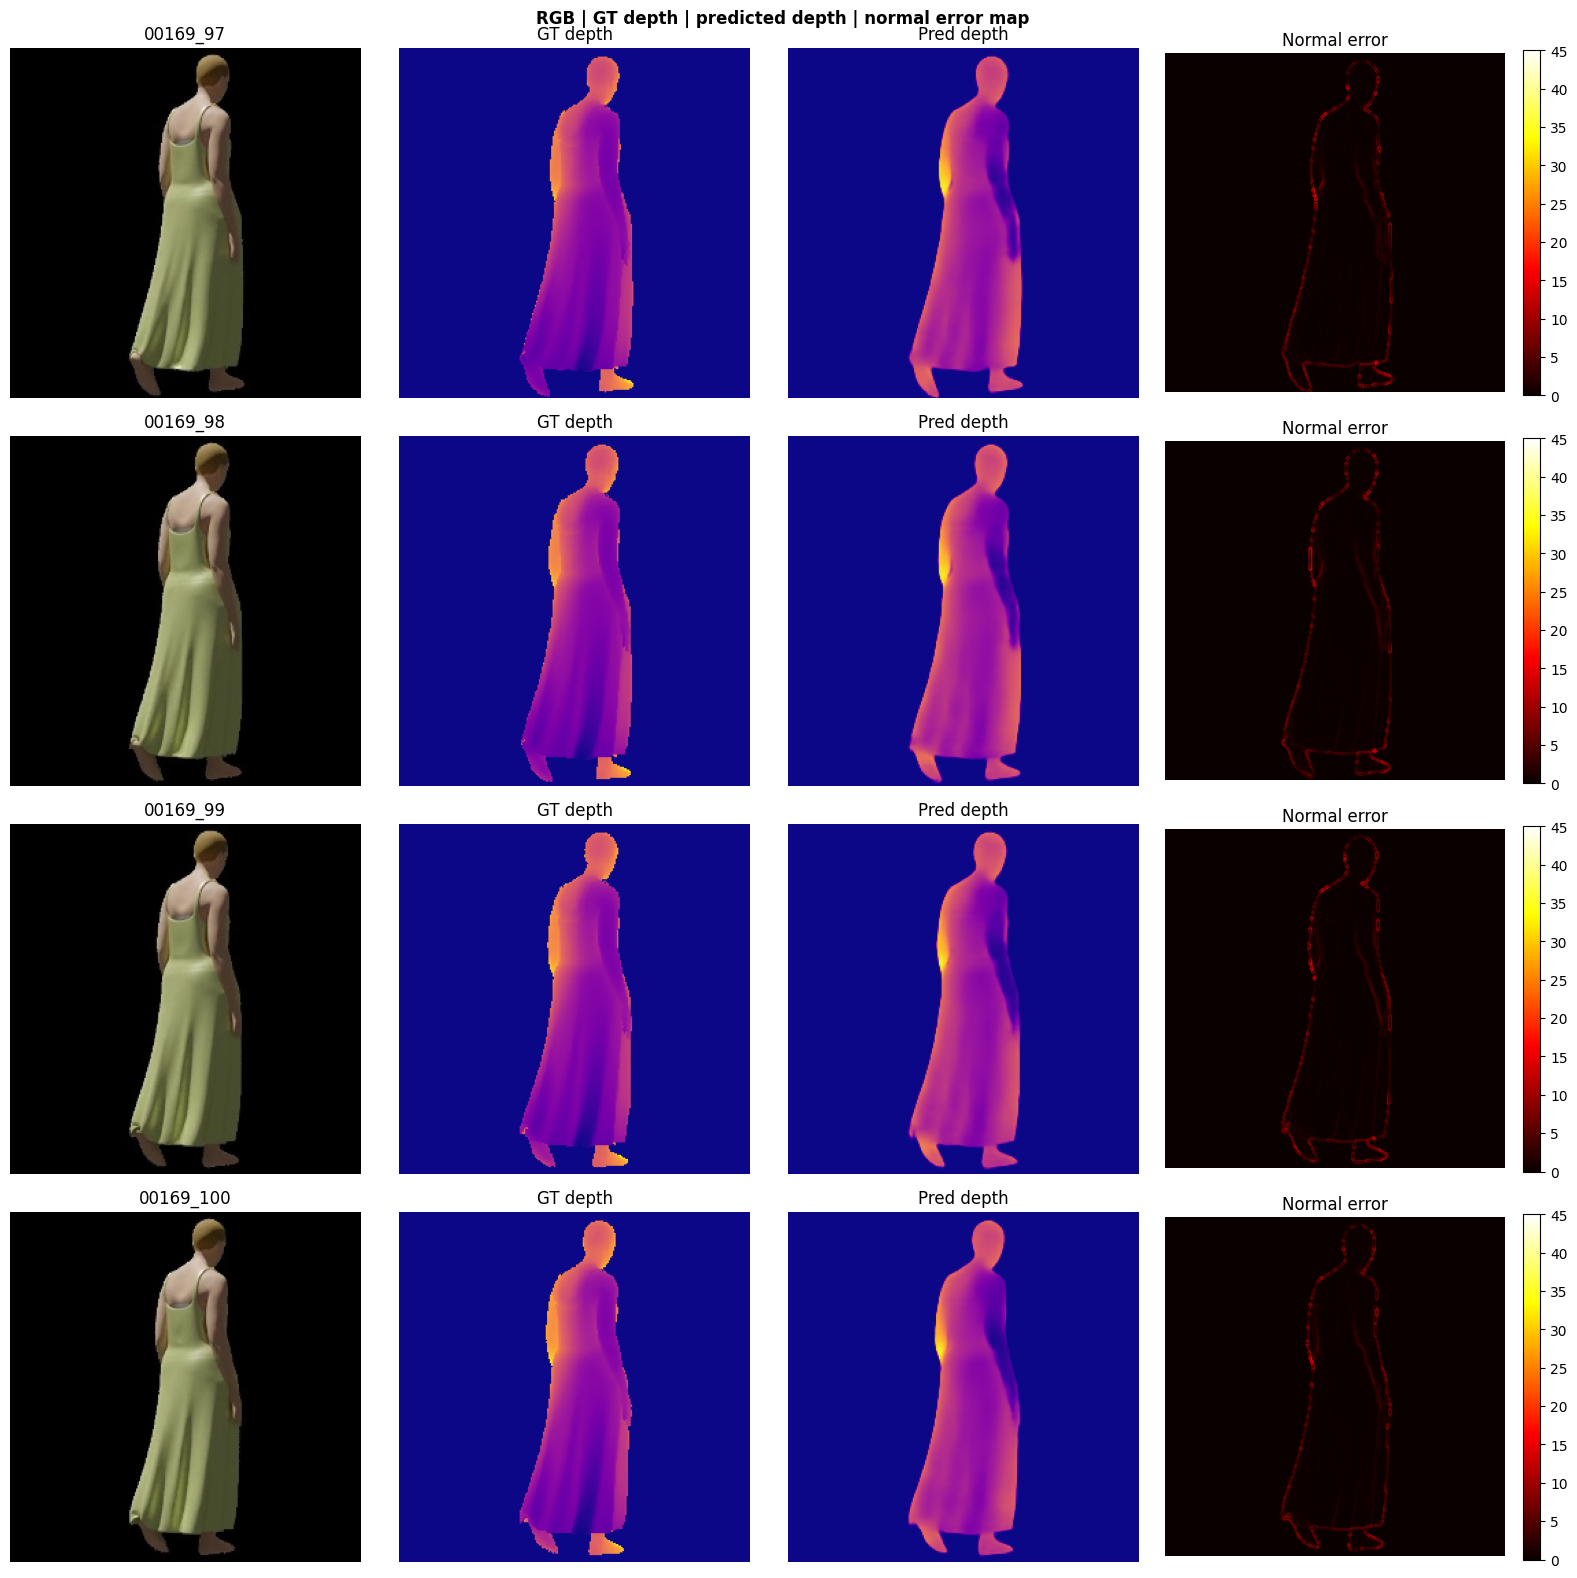

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit\figures\predictions_deit_p8_bilinear_full_finetune_lr1e_4_bs4.png


In [13]:
@torch.no_grad()
def visualize_predictions(result, n_samples=4):
    cfg = build_cfg({
        'patch_size': int(result['patch_size']),
        'decoder': result['decoder'],
        'transfer': result['transfer'],
        'lr': result['lr'],
        'batch_size': int(result['batch_size']),
    })
    model = build_model(cfg).to(DEVICE)
    apply_transfer_learning(model, cfg['transfer'])
    model.load_state_dict(torch.load(result['checkpoint'], map_location=DEVICE, weights_only=True))
    model.eval()
    ds = Cloth3DDataset(test_list, cfg['root'], cfg['img_size'])
    n_samples = min(n_samples, len(ds))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('RGB | GT depth | predicted depth | normal error map', fontweight='bold')
    for i in range(n_samples):
        X, Y = ds[i]
        pred = model(X.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)
        rgb = X.permute(1, 2, 0).numpy()
        rgb = (rgb * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        gt_np = Y.squeeze().numpy()
        pred_np = pred.squeeze().numpy()
        n_pred = depth_to_normals(pred.unsqueeze(0))
        n_gt = depth_to_normals(Y.unsqueeze(0))
        err_map = (torch.acos((n_pred * n_gt).sum(dim=1).clamp(-1, 1)) * 180.0 / torch.pi).squeeze().numpy()
        axes[i, 0].imshow(rgb); axes[i, 0].set_title(test_list[i])
        axes[i, 1].imshow(gt_np, cmap='plasma'); axes[i, 1].set_title('GT depth')
        axes[i, 2].imshow(pred_np, cmap='plasma'); axes[i, 2].set_title('Pred depth')
        im = axes[i, 3].imshow(err_map, cmap='hot', vmin=0, vmax=45); axes[i, 3].set_title('Normal error')
        plt.colorbar(im, ax=axes[i, 3], fraction=0.046)
        for ax in axes[i]:
            ax.axis('off')
    plt.tight_layout()
    out = FIG_ROOT / f'predictions_{slugify(result["label"])}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


visualize_predictions(STAGE_DECISIONS['best_transfer'])
cleanup_cuda()


## 10 - Discussion Notes

### Do transformers preserve spatial detail?

The controlled patch-size comparison suggests that spatial detail is sensitive to token resolution. With the same bilinear decoder and full fine-tuning, DeiT-Small patch 8 achieved the best Task 2 result: validation RMSE 0.0735, test RMSE 0.0537, and normal MAE 1.02 deg. Patch 16 was close but worse, with validation RMSE 0.0772, test RMSE 0.0578, and normal MAE 1.17 deg.

This indicates that transformers can preserve enough spatial structure for dense depth when the patch grid is fine enough and the encoder is pretrained. However, the detail is not as native as in a CNN: DeiT first converts the image into patch tokens, so sub-patch boundaries and thin cloth structures must be recovered by the decoder from token-level features. Patch 8 helped because each token covers a smaller image area.

### Where do transformers fail vs CNNs?

Compared with the Task 1 UNet baseline, the best DeiT model improved depth accuracy substantially: UNet validation RMSE was 0.0889 and test RMSE was 0.0660, while DeiT patch 8 reached 0.0735 validation RMSE and 0.0537 test RMSE. The tradeoff is efficiency: UNet ran at about 179.7 FPS, while the best DeiT model ran at about 61.5 FPS.

The transformer is therefore better for global shape and overall depth consistency, but it can still struggle around silhouettes, hands, feet, cloth hems, and sharp folds because those are localized geometric details. CNNs have a stronger local inductive bias and are faster in this setup, while DeiT benefits more from ImageNet pretraining and global self-attention.

### What matters most: transfer learning, patch size, or decoder design?

The largest factor was transfer learning. Freezing the patch-8 backbone gave validation RMSE 0.0950, which was worse than both the full fine-tuned transformer and the UNet baseline. Full fine-tuning was essential because the ImageNet features needed to adapt to dense depth estimation.

Patch size was the next most useful factor. Moving from patch 16 to patch 8 improved validation RMSE from 0.0772 to 0.0735 and improved normal MAE from 1.17 deg to 1.02 deg.

Decoder design did not help in our runs. The lightweight FPN decoder with patch 16 reached validation RMSE 0.0904, much worse than the simple bilinear decoder at 0.0772. This suggests that for this DeiT setup, preserving a clean pretrained representation and using a simple decoder was better than adding a small FPN over a single-scale feature map.

### Architecture, memory vs speed, and performance vs CNN

The selected architecture is:

RGB crop -> DeiT patch embedding -> transformer encoder blocks -> patch tokens reshaped into a 2D feature map -> bilinear upsampling decoder -> sigmoid depth map.

The best DeiT model had about 23.0M parameters, compared with about 31.0M for the UNet baseline. Even with fewer parameters, DeiT was slower because self-attention and token processing are computationally heavier. The final Task 2 choice was DeiT-Small patch 8 with bilinear decoder and full fine-tuning because it gave the best accuracy, while UNet remained the better speed-oriented model.
